## Analytics VSL400 dataset

In [1]:
import json
import os
import pandas as pd

# Create file gloss.csv, which contains all video's information
def create_gloss_csv(json_paths, output_path):
    unique_glosses = set()
    for json_path in json_paths:
        print(f"Reading data from json file: {json_path}")
        if not os.path.exists(json_path):
            print(f"File {json_path} does not exist")
            return

        with open(json_path, "r", encoding='utf-8') as f:
            data = json.load(f)

        for item in data:
            if 'gloss' in item and item['gloss']:
                unique_glosses.add(item['gloss'].strip())

    sorted_glosses = sorted(list(unique_glosses))
    df = pd.DataFrame({
        'id': range(len(unique_glosses)),
        'gloss': sorted_glosses
    })
    print(df.head())

    df.to_csv(output_path, index=False, header=True, encoding='utf-8')

# run
create_gloss_csv(['./root/front_view.json', './root/left_view.json', './root/right_view.json'], './root/gloss.csv')

Reading data from json file: ./root/front_view.json
Reading data from json file: ./root/left_view.json
Reading data from json file: ./root/right_view.json
   id       gloss
0   0         Anh
1   1       Ba lô
2   2         Bia
3   3  Buổi chiều
4   4   Buổi sáng


In [2]:
from pathlib import Path
import os
import json
import pandas as pd

def create_df_information(json_paths, output_path):
    headers = ['VIDEO_ID', 'SIGNER_ID', 'FPS', 'RESOLUTION', 'GLOSS', 'NUM_FRAMES', 'LENGTH_SECONDS']

    data_jsons = []
    for json_path in json_paths:
        if not os.path.exists(json_path):
            print(f"File {json_path} does not exist")
            return

        with open(json_path, "r", encoding='utf-8') as f:
            data = json.load(f)
            view_name = Path(json_path).stem.split('_')[0]
            if isinstance(data, list):
                for item in data:
                    item['view'] = view_name
                data_jsons.extend(data)
            else:
                data['view'] = view_name
                data_jsons.append(data)

    df = pd.DataFrame(data_jsons)
    df.columns = df.columns.str.upper()

    if 'VIEW' in df.columns:
        col_view = df.pop('VIEW')
        df.insert(0, 'VIEW', col_view)

    df.to_csv(output_path, index=False, header=True, encoding='utf-8-sig')

# run
create_df_information(['./root/front_view.json', './root/left_view.json', './root/right_view.json'], './root/analytics.csv')


### Visulization VSL400 Dataset

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./root/analytics.csv', encoding='utf-8-sig', dtype={'VIDEO_ID': str, 'SIGNER_ID': str})
print(df)
print("="*50)
print('Len dataframe: ',len(df))

        VIEW VIDEO_ID SIGNER_ID   FPS  RESOLUTION     GLOSS  NUM_FRAMES  LENGTH_SECONDS
0      front   000000       001  25.0        1080       Anh          65            2.60
1      front   000001       001  25.0        1080       Anh          56            2.24
2      front   000002       001  25.0        1080       Chị          62            2.48
3      front   000003       001  25.0        1080       Chị          76            3.04
4      front   000004       001  25.0        1080        Em          65            2.60
...      ...      ...       ...   ...         ...       ...         ...             ...
74254  right   024770       028  25.0        1080  Tốt bụng          58            2.32
74255  right   024771       028  25.0        1080    Thú vị          64            2.56
74256  right   024772       028  25.0        1080  Hài hước          49            1.96
74257  right   024773       028  25.0        1080  Dũng cảm          66            2.64
74258  right   024774       028 

                 GLOSS  NUM_VIDEO
0               Mùa hè        279
1                 Ngày        267
2                 Nắng        261
3                  Ướt        258
4                  Nhẹ        255
..                 ...        ...
395           Túi xách        162
396           Áo sơ mi        162
397             Xe đạp        162
398  Nhân viên phục vụ        159
399             Thư ký        159

[400 rows x 2 columns]
Len gloss: 400 vocabulary
Sum num video: 74259


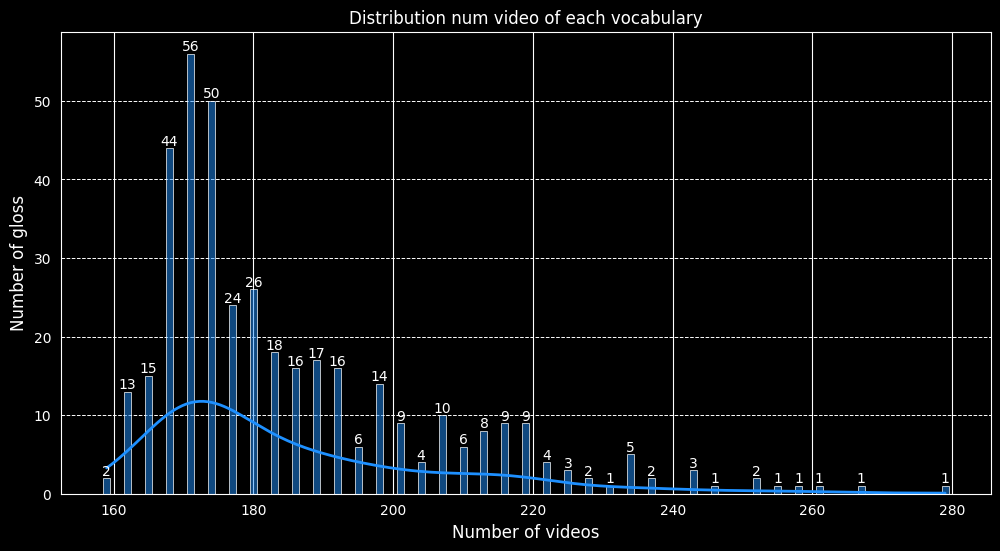

In [4]:
df_gloss = df.groupby('GLOSS')['VIDEO_ID'].count().reset_index()
df_gloss.columns = ['GLOSS', 'NUM_VIDEO']
df_gloss = df_gloss.sort_values(by='NUM_VIDEO', ascending=False).reset_index(drop=True)
print(df_gloss)
print("="*50)
print(f"Len gloss: {len(set(df['GLOSS']))} vocabulary")
print(f"Sum num video: {df_gloss['NUM_VIDEO'].sum()}")
print("="*50)
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df_gloss, x='NUM_VIDEO', discrete=True, color='dodgerblue',kde=True,line_kws={'linewidth': 2})
plt.title('Distribution num video of each vocabulary')
plt.xlabel('Number of videos', fontsize=12)
plt.ylabel('Number of gloss', fontsize=12)
plt.grid(axis='y', linestyle='--', linewidth=0.7)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)
plt.show()

    VIEW  NUM_VIDEO
0  front      24753
1   left      24753
2  right      24753


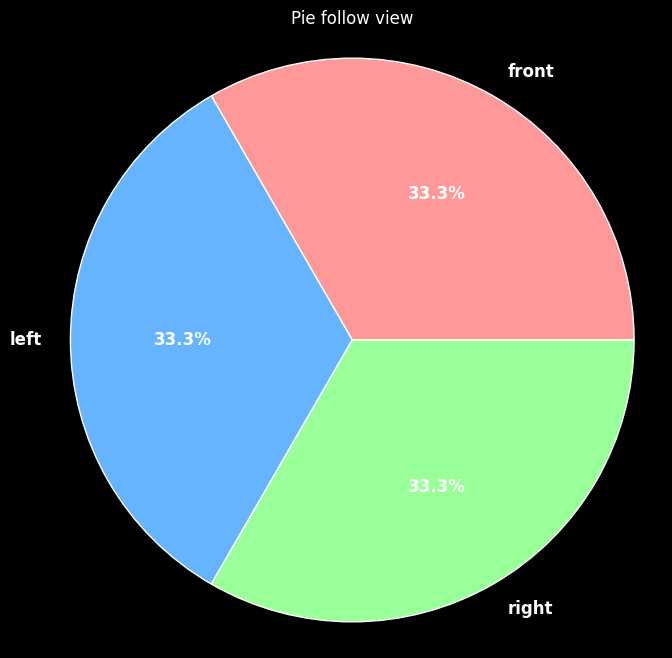

In [5]:
df_view = df.groupby('VIEW')['VIDEO_ID'].count().reset_index()
df_view.columns = ['VIEW', 'NUM_VIDEO']
print(df_view)
print("="*50)
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.figure(figsize=(8,8))
plt.pie(df_view['NUM_VIDEO'], labels=df_view['VIEW'], colors=colors ,autopct='%1.1f%%', textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Pie follow view')
plt.axis('equal')
plt.show()

     LENGTH_SECONDS  COUNT
0              1.20      1
1              1.24      1
2              1.32      3
3              1.36      3
4              1.52     24
..              ...    ...
101            5.56      1
102            5.68      1
103            5.72      1
104            5.76      1
105            5.88      1

[106 rows x 2 columns]


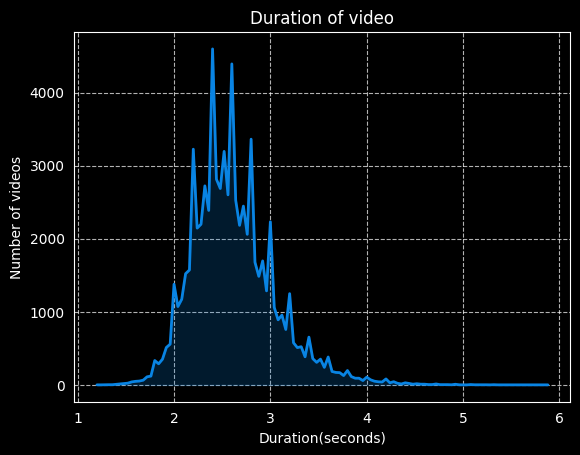

In [8]:
df_duration = df.groupby("LENGTH_SECONDS")['VIDEO_ID'].count().reset_index(name='COUNT')
df_duration = df_duration.sort_values('LENGTH_SECONDS')
print(df_duration)
sns.lineplot(data=df_duration, x="LENGTH_SECONDS", y="COUNT", color='#0984e3', linewidth=2)
plt.fill_between(df_duration['LENGTH_SECONDS'], df_duration['COUNT'], color='#0984e3', alpha=0.2)
plt.title("Duration of video")
plt.xlabel('Duration(seconds)')
plt.ylabel('Number of videos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
df_person = df.groupby("SIGNER_ID")['VIDEO_ID'].count().reset_index(name='COUNT')
df_person = df_person.sort_values('COUNT').reset_index(drop=True)
print(df_person)
print("="*50)

   SIGNER_ID  COUNT
0        028   2100
1        027   2400
2        008   2445
3        019   2448
4        013   2475
5        018   2484
6        007   2490
7        006   2499
8        002   2523
9        012   2526
10       003   2550
11       021   2553
12       016   2568
13       004   2574
14       001   2583
15       022   2616
16       023   2616
17       010   2676
18       014   2781
19       011   2808
20       020   2988
21       009   3093
22       025   3162
23       015   3465
24       024   5277
25       026   5559
       GLOSS SIGNER_ID  VIDEO_COUNT
0        Anh       001            2
1        Anh       002            2
2        Anh       003            2
3        Anh       004            2
4        Anh       006            3
...      ...       ...          ...
10390  Ồn ào       024            6
10391  Ồn ào       025            4
10392  Ồn ào       026            6
10393  Ồn ào       027            2
10394  Ồn ào       028            2

[10395 rows x 3 columns]


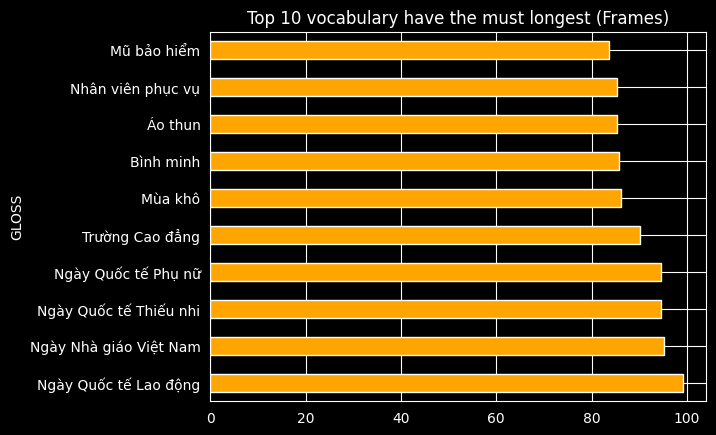

In [15]:
df_complexity = df.groupby('GLOSS')['NUM_FRAMES'].mean().sort_values(ascending=False).head(10)
df_complexity.plot(kind='barh', color='orange')
plt.title('Top 10 vocabulary have the must longest (Frames)')
plt.show()

/tmp/ipykernel_1518470/3414239181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, y='SIGNER_ID', x='CV', palette='viridis', width=0.7)


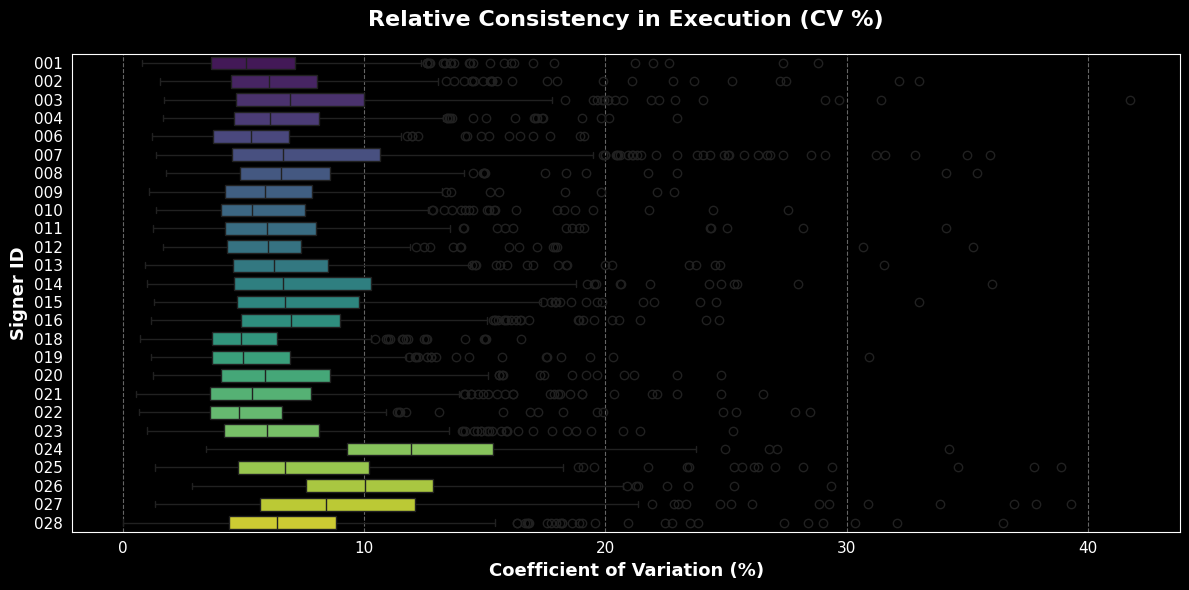

In [22]:
df_stats = df.groupby(['SIGNER_ID', 'GLOSS'])['LENGTH_SECONDS'].agg(['std', 'mean']).reset_index()

df_stats['CV'] = (df_stats['std'] / df_stats['mean']) * 100

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_stats, y='SIGNER_ID', x='CV', palette='viridis', width=0.7)

plt.title('Relative Consistency in Execution (CV %)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coefficient of Variation (%)', fontsize=13, fontweight='bold')
plt.ylabel('Signer ID', fontsize=13, fontweight='bold')
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
gloss_stats = df.groupby('GLOSS')['LENGTH_SECONDS'].agg(['mean', 'std']).reset_index()
df_check = df.merge(gloss_stats, on='GLOSS')
outliers = df_check[abs(df_check['LENGTH_SECONDS'] - df_check['mean']) > 3 * df_check['std']]
print("Anomaly video (Check again):")
print(outliers[['VIDEO_ID', 'GLOSS', 'SIGNER_ID', 'LENGTH_SECONDS', 'mean']].head(10))

print(f"Video can be error: {len(outliers)}")

Danh sách các Video có thời lượng bất thường (Cần kiểm tra lại):
     VIDEO_ID       GLOSS SIGNER_ID  LENGTH_SECONDS      mean
2408   002410          Mẹ       003            3.76  2.281170
2808   002812         Kem       004            3.52  2.518391
3382   003386         Mập       004            3.40  2.191398
3383   003387         Mập       004            3.40  2.191398
3601   003605     Bây giờ       006            3.40  2.303509
3976   003980  Hay (khen)       006            3.40  2.477419
3977   003981  Hay (khen)       006            3.40  2.477419
3980   003984        Nặng       006            3.40  2.305812
3981   003985        Nặng       006            3.40  2.305812
4697   004702         Nên       007            3.44  2.386854

Tổng số video nghi ngờ là lỗi: 528


/tmp/ipykernel_1518470/2139769031.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RESOLUTION', palette='viridis')


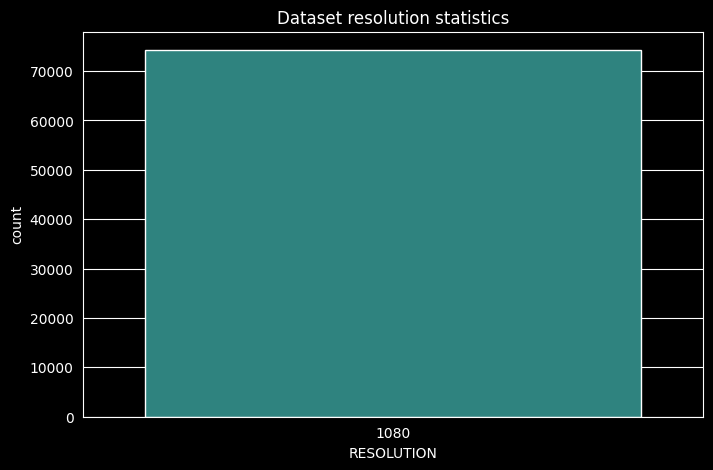

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='RESOLUTION', palette='viridis')
plt.title('Dataset resolution statistics')
plt.show()